In [51]:
# packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
# read the original data
children = pd.read_csv('child24.csv')


In [53]:
# DEMOGRAPHICS

demographics = ["SEX_C", "RELTIVP_C", "RACEALLP_C"]

# MAIN OUTCOME
main_outcome = ["PHSTAT_C"]

# PSYCHOSOCIAL COVARIATES
psychosocial_covariates = ["ANXFREQ_C", "DEPFREQ_C", "SCHDYMSSTC_C"]

# SOCIAL DETERMINANTS OF HEALTH COVARIATES

# Income, Insurance

social_determinants = ["NOTCOV_C", "COVER_C", "FSNAP12M_C", "FWIC12M_C", "FLUNCH12M1_C"]

# Education
education = ["MAXPAREDUP_C"]

# Food Security

# FDSCAT34_C
food_security = ["FDSCAT3_C", "FDSCAT4_C"]

# Housing
housing = ["HOUTENURE_C"]

# Built Environment
built_environment = ["SIDEWALK_C", "PARKS_C", "TRAFFIC_C", "CRIME_C"]

# ELIGIBILITY
eligibility = ["AGEP_C", "CURFOOD_C"]

# Variables
variables = [
    *demographics,
    *main_outcome,
    *psychosocial_covariates,
    *social_determinants,
    *education,
    *food_security,
    *housing,
    *built_environment,
    *eligibility
]


child_data = children[variables]

In [54]:
# Limit the age range

children_with_age_range = child_data[
    child_data["AGEP_C"].between(5, 17)
]

# children_with_age_range

## Exploratory Data Analysis (EDA)   

### Sample Overview

- Total number of surveyed children
- The number of surveyed children in selected age range 5 to 17

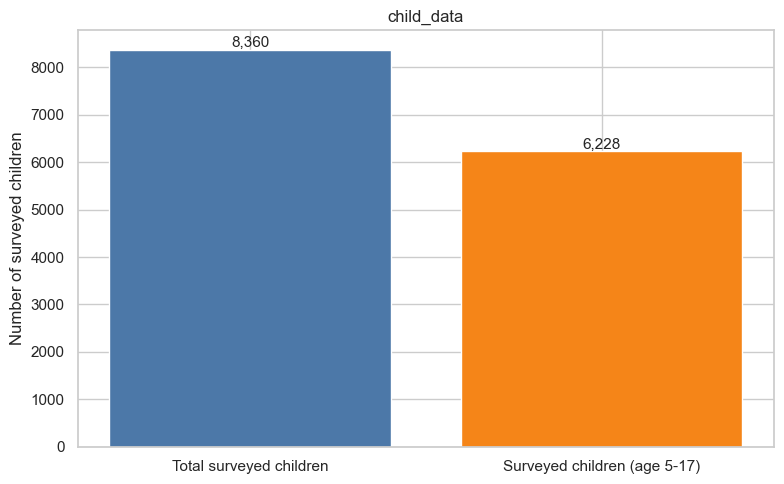

In [55]:
# Sample Overview

total_children = child_data.shape[0]
children_5_to_17 = children_with_age_range.shape[0]

sample_overview = pd.DataFrame({
    "Group": ["Total surveyed children", "Surveyed children (age 5-17)"],
    "Count": [total_children, children_5_to_17]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(sample_overview["Group"], sample_overview["Count"], color=["#4C78A8", "#F58518"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("child_data")
plt.ylabel("Number of surveyed children")
plt.xlabel("")
plt.tight_layout()
plt.show()


### Demographics

- The number of children by age
- The number of children by sex
- The number of children by race/ethnicity

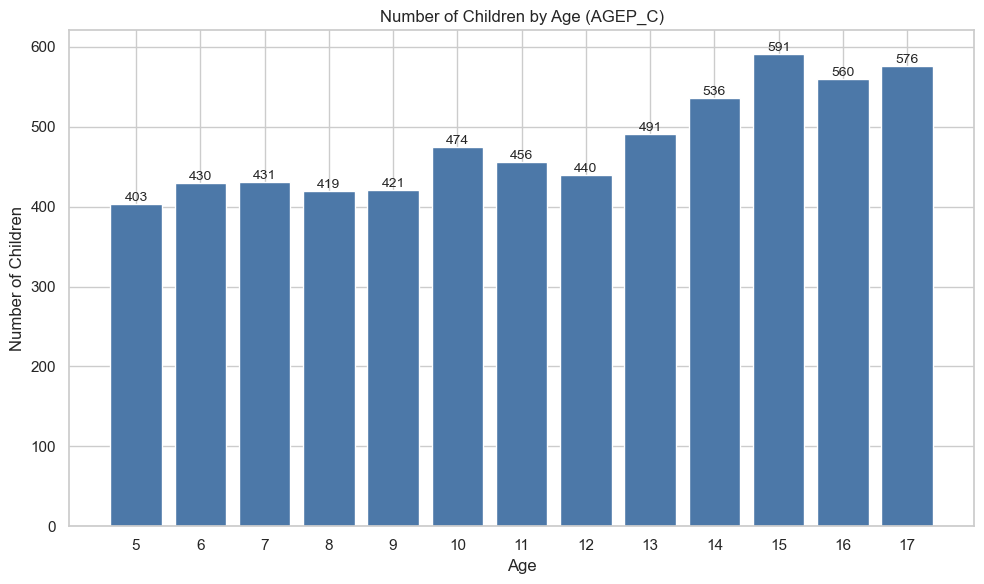

In [56]:
# Demographics - Bar chart 1: Number of children by age (5 to 17)

age_series = pd.to_numeric(child_data["AGEP_C"], errors="coerce")
age_5_to_17 = age_series[age_series.between(5, 17)]

# Keep all ages from 5 to 17 on the x-axis, filling missing ages with 0
age_counts = age_5_to_17.value_counts().reindex(range(5, 18), fill_value=0)

plt.figure(figsize=(10, 6))
bars = plt.bar(age_counts.index.astype(str), age_counts.values, color="#4C78A8")

# Show exact counts above each bar
for bar, value in zip(bars, age_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children by Age (AGEP_C)")
plt.xlabel("Age")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()


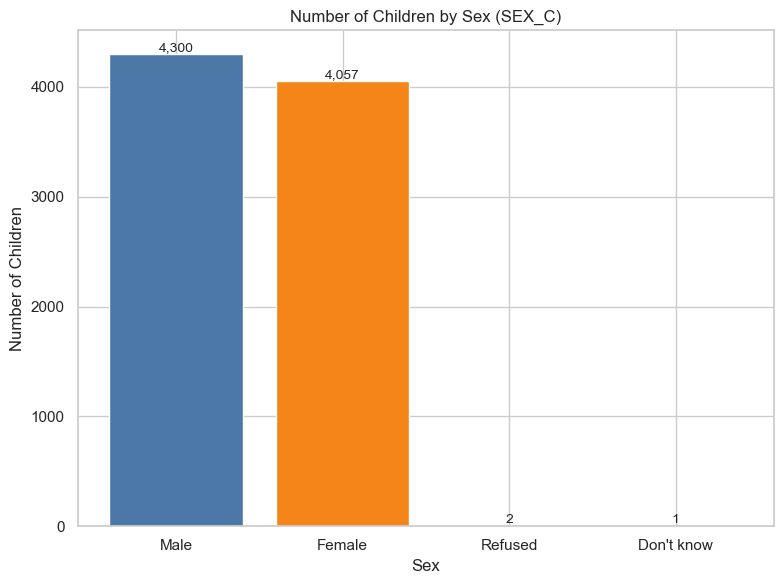

In [57]:
#| hide_input
# Demographics - Bar chart 2: Number of children by sex

sex_labels_map = {
    1: "Male",
    2: "Female",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

sex_series = pd.to_numeric(child_data["SEX_C"], errors="coerce")
sex_counts = sex_series.value_counts().sort_index()
sex_labels = [sex_labels_map.get(int(code), f"Code {int(code)}") for code in sex_counts.index]

# Use a different color for each bar
bar_colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"][:len(sex_counts)]

plt.figure(figsize=(8, 6))
bars = plt.bar(sex_labels, sex_counts.values, color=bar_colors)

# Show exact counts above each bar
for bar, value in zip(bars, sex_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children by Sex (SEX_C)")
plt.xlabel("Sex")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()


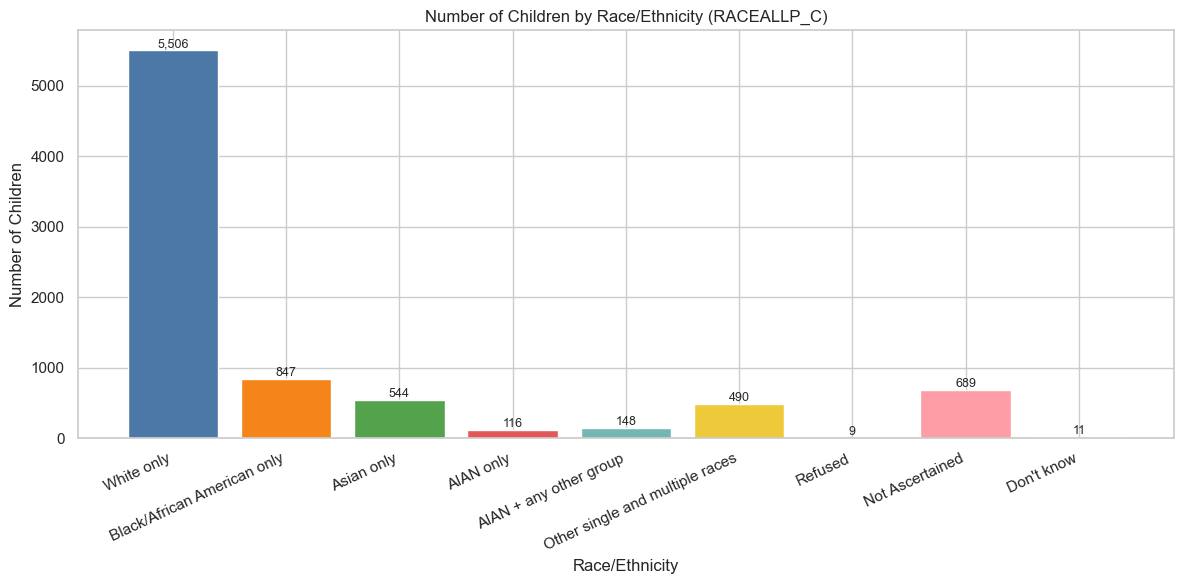

In [58]:
# Demographics - Bar chart 3: Number of children by race/ethnicity

race_labels_map = {
    1: "White only",
    2: "Black/African American only",
    3: "Asian only",
    4: "AIAN only",
    5: "AIAN + any other group",
    6: "Other single and multiple races",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

race_series = pd.to_numeric(child_data["RACEALLP_C"], errors="coerce")
race_counts = race_series.value_counts().sort_index()
race_labels = [race_labels_map.get(int(code), f"Code {int(code)}") for code in race_counts.index]

# Use a different color for each bar
bar_colors = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
    "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D"
][:len(race_counts)]

plt.figure(figsize=(12, 6))
bars = plt.bar(race_labels, race_counts.values, color=bar_colors)

# Show exact counts above each bar
for bar, value in zip(bars, race_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Number of Children by Race/Ethnicity (RACEALLP_C)")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Number of Children")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Food Allergy

- The number of children with current food allergy (CURFOOD_C)
- Percentage of children with current food allergy

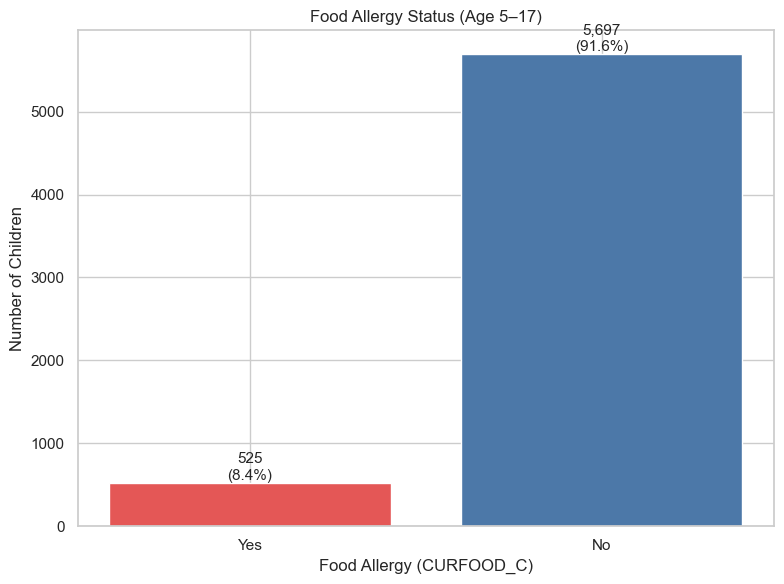

In [ ]:
food_series = pd.to_numeric(
    children_with_age_range["CURFOOD_C"], errors="coerce"
)
food_series = food_series[food_series.isin([1, 2])]

# count
counts = food_series.value_counts().reindex([1, 2], fill_value=0)

# percentage
percentages = (counts / counts.sum()) * 100

# labels & colors
labels = ["Yes", "No"]
colors = ["#E45756", "#4C78A8"]

# graph
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts.values, color=colors)

# count + percentage
for bar, count, pct in zip(bars, counts.values, percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(count):,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Food Allergy Status (Age 5–17)")
plt.xlabel("Food Allergy (CURFOOD_C)")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()

- The number of children having food allergy by sex
- The number of children having food allergy by age
- The number of children having food allergy by race/ethnicity

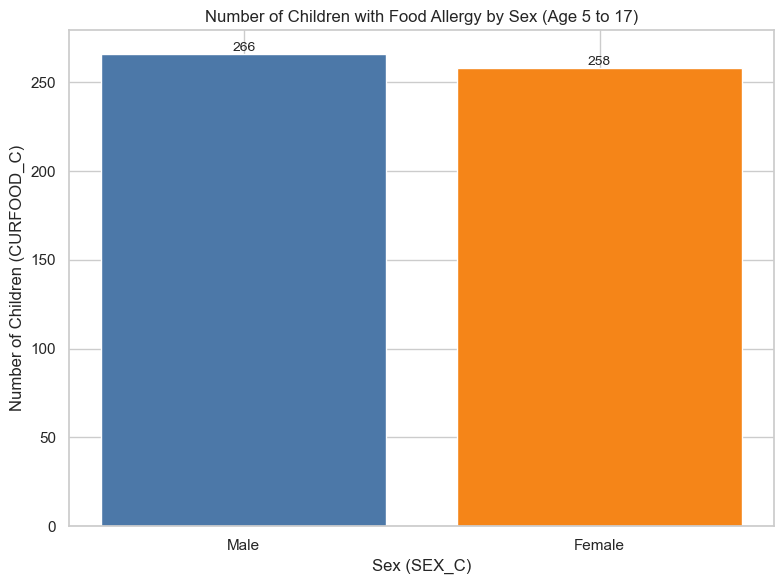

In [60]:
#| hide_input
# The number of children having food allergy by sex (Male/Female only, age 5-17)

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Keep only Male(1), Female(2)
sex_series = pd.to_numeric(allergy_yes["SEX_C"], errors="coerce")
sex_series = sex_series[sex_series.isin([1, 2])]

# Fixed order: Male, Female
sex_counts = sex_series.value_counts().reindex([1, 2], fill_value=0)
sex_labels = ["Male", "Female"]
bar_colors = ["#4C78A8", "#F58518"]

plt.figure(figsize=(8, 6))
bars = plt.bar(sex_labels, sex_counts.values, color=bar_colors)

# Show exact counts on bars
for bar, value in zip(bars, sex_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children with Food Allergy by Sex (Age 5 to 17)")
plt.xlabel("Sex (SEX_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.tight_layout()
plt.show()


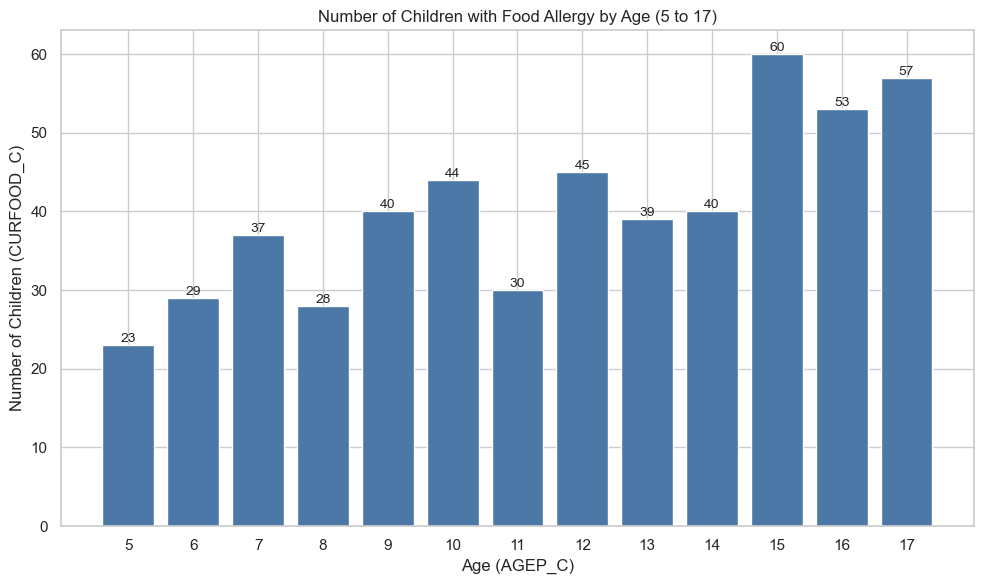

In [61]:
# The number of children having food allergy by age (5 to 17)

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Keep valid ages 5-17
age_series = pd.to_numeric(allergy_yes["AGEP_C"], errors="coerce")
age_series = age_series[age_series.between(5, 17)]

# Fixed age order 5~17, fill missing ages with 0
age_counts = age_series.value_counts().reindex(range(5, 18), fill_value=0)

plt.figure(figsize=(10, 6))
bars = plt.bar(age_counts.index.astype(str), age_counts.values, color="#4C78A8")

# Show exact counts on bars
for bar, value in zip(bars, age_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children with Food Allergy by Age (5 to 17)")
plt.xlabel("Age (AGEP_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.tight_layout()
plt.show()

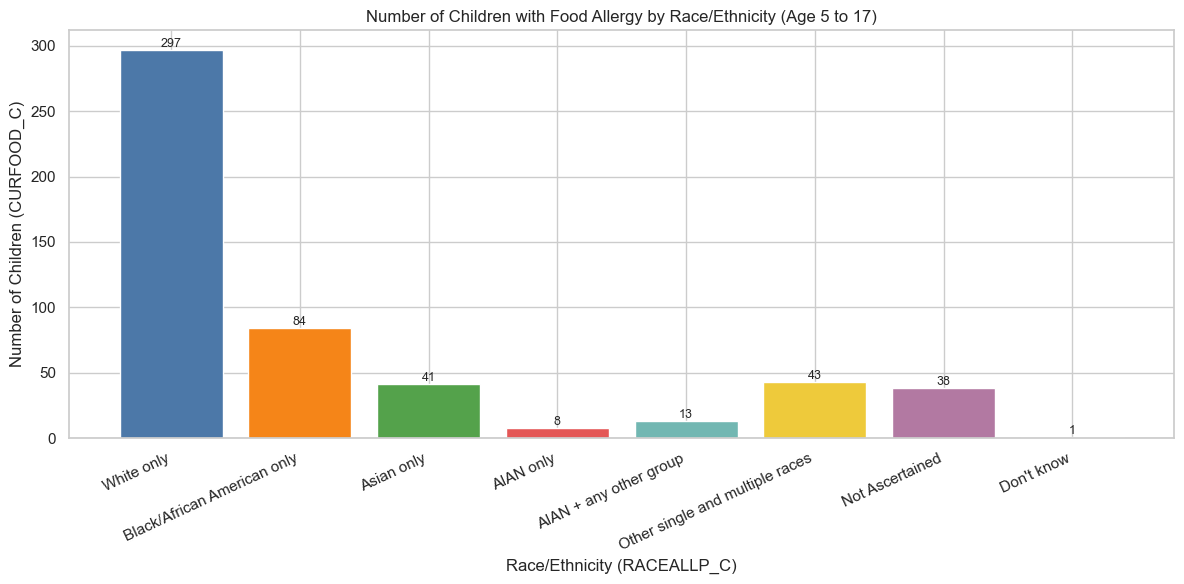

In [62]:
# The number of children having food allergy by race/ethnicity (age 5 to 17)

race_labels_map = {
    1: "White only",
    2: "Black/African American only",
    3: "Asian only",
    4: "AIAN only",
    5: "AIAN + any other group",
    6: "Other single and multiple races",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Count by race/ethnicity
race_series = pd.to_numeric(allergy_yes["RACEALLP_C"], errors="coerce")
race_counts = race_series.value_counts().sort_index()
race_labels = [race_labels_map.get(int(code), f"Code {int(code)}") for code in race_counts.index]

bar_colors = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
    "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D"
][:len(race_counts)]

plt.figure(figsize=(12, 6))
bars = plt.bar(race_labels, race_counts.values, color=bar_colors)

# Show exact counts on bars
for bar, value in zip(bars, race_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Number of Children with Food Allergy by Race/Ethnicity (Age 5 to 17)")
plt.xlabel("Race/Ethnicity (RACEALLP_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


# Analysis

What factors are associated with health status among children with food allergies?  
How does this differ when compared to children without food allergies?

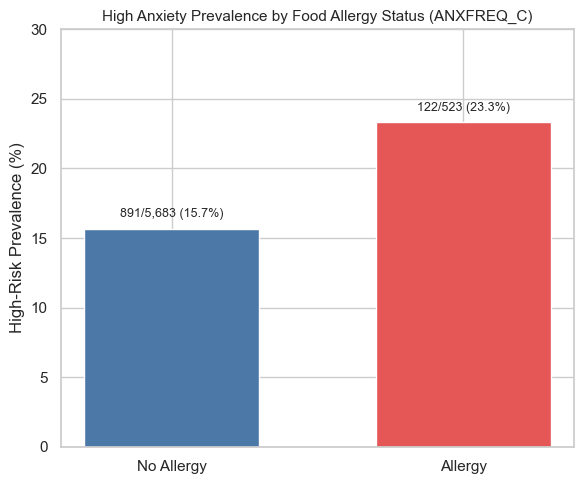

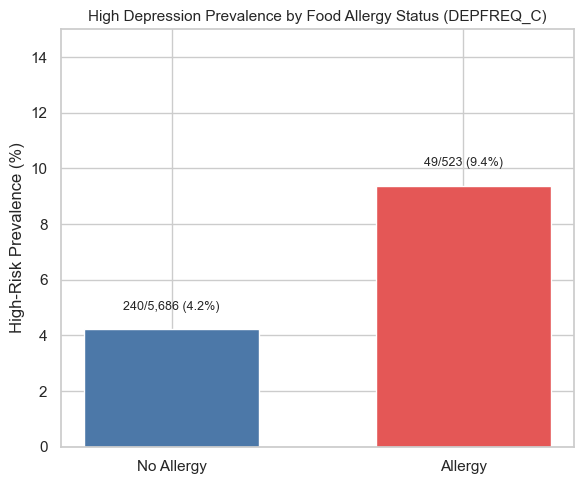

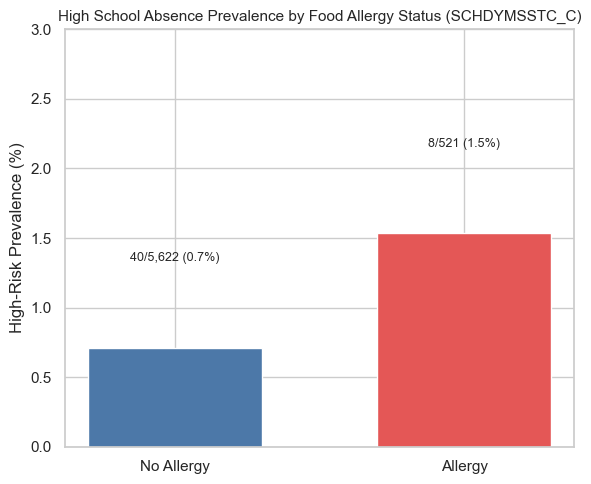


=== high_anxiety ===


high_anxiety,Not High-Risk,High-Risk
food_allergy,,
No Allergy,4792,891
Allergy,401,122


chi2 = 19.9569, p-value = 7.92095e-06, dof = 1

=== high_depression ===


high_depression,Not High-Risk,High-Risk
food_allergy,,
No Allergy,5446,240
Allergy,474,49


chi2 = 27.4546, p-value = 1.60825e-07, dof = 1

=== high_absence ===


high_absence,Not High-Risk,High-Risk
food_allergy,,
No Allergy,5582,40
Allergy,513,8


chi2 = 3.1808, p-value = 0.0745073, dof = 1


In [63]:
from scipy.stats import chi2_contingency

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# CURFOOD_C: 1=Allergy, 2=No Allergy, others=NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# ANXFREQ_C: 1,2 -> 1 (High Anxiety), 3,4,5 -> 0, 7,8,9 -> NaN
anx = pd.to_numeric(df["ANXFREQ_C"], errors="coerce")
df["high_anxiety"] = np.where(
    anx.isin([1, 2]), 1,
    np.where(anx.isin([3, 4, 5]), 0, np.nan)
)

# DEPFREQ_C: 1,2 -> 1 (High Depression), 3,4,5 -> 0, 7,8,9 -> NaN
dep = pd.to_numeric(df["DEPFREQ_C"], errors="coerce")
df["high_depression"] = np.where(
    dep.isin([1, 2]), 1,
    np.where(dep.isin([3, 4, 5]), 0, np.nan)
)

# SCHDYMSSTC_C: 40~95 -> 1 (High Absence), 0~39 -> 0, 96~99 -> NaN
sch = pd.to_numeric(df["SCHDYMSSTC_C"], errors="coerce")
df["high_absence"] = np.where(
    (sch >= 40) & (sch <= 95), 1,
    np.where((sch >= 0) & (sch <= 39), 0, np.nan)
)

# -----------------------------------
# 2) Separate plots (one by one)
# -----------------------------------
sns.set_theme(style="whitegrid")

outcomes = [
    ("high_anxiety", "High Anxiety Prevalence by Food Allergy Status (ANXFREQ_C)"),
    ("high_depression", "High Depression Prevalence by Food Allergy Status (DEPFREQ_C)"),
    ("high_absence", "High School Absence Prevalence by Food Allergy Status (SCHDYMSSTC_C)"),
]

colors = ["#4C78A8", "#E45756"]  # No Allergy, Allergy
chi_results = []

for outcome, title in outcomes:
    sub = df.dropna(subset=["food_allergy", outcome]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[outcome] = sub[outcome].astype(int)

    ct = pd.crosstab(sub["food_allergy"], sub[outcome]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )

    high_counts = ct[1]
    totals = ct.sum(axis=1)
    high_pct = high_counts / totals * 100

    # One figure per outcome
    plt.figure(figsize=(6, 5))
    x_labels = ["No Allergy", "Allergy"]
    y_vals = [high_pct.loc[0], high_pct.loc[1]]
    bars = plt.bar(x_labels, y_vals, color=colors, width=0.6)

    for i, grp in enumerate([0, 1]):
        cnt = int(high_counts.loc[grp])
        tot = int(totals.loc[grp])
        pct = float(high_pct.loc[grp])
        plt.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 0.6,
            f"{cnt:,}/{tot:,} ({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.title(title, fontsize=11)
    plt.ylabel("High-Risk Prevalence (%)")
    if outcome == "high_anxiety":
        plt.ylim(0, 30)
    elif outcome == "high_depression":
        plt.ylim(0, 15)
    else:
        plt.ylim(0, 3)
    plt.tight_layout()
    plt.show()

    # Chi-square
    chi2, p, dof, exp = chi2_contingency(ct)
    chi_results.append({
        "Outcome": outcome,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "crosstab": ct
    })

# -----------------------------------
# 3) Crosstabs + chi-square results
# -----------------------------------
for r in chi_results:
    print(f"\n=== {r['Outcome']} ===")
    ct_show = r["crosstab"].rename(
        index={0: "No Allergy", 1: "Allergy"},
        columns={0: "Not High-Risk", 1: "High-Risk"}
    )
    display(ct_show)
    print(f"chi2 = {r['chi2']:.4f}, p-value = {r['p_value']:.6g}, dof = {r['dof']}")


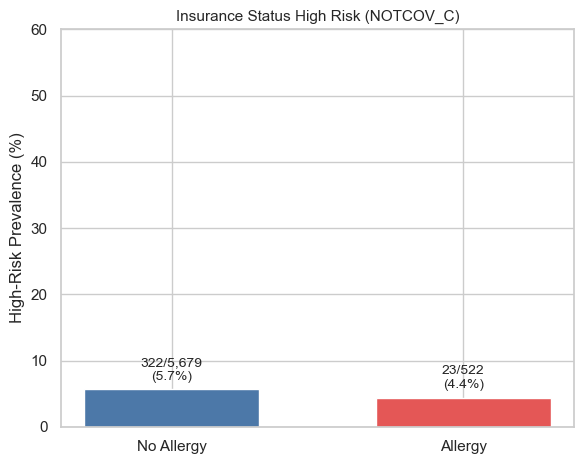

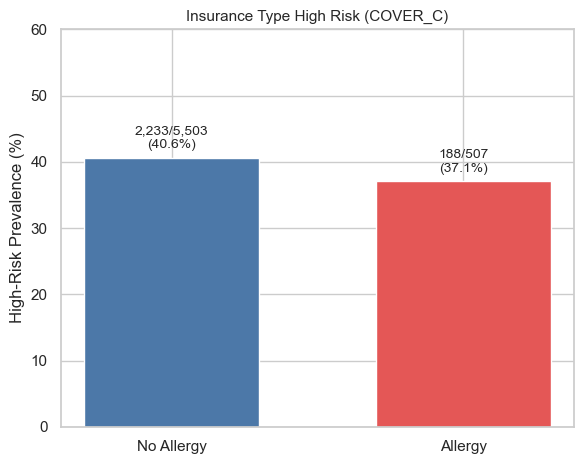

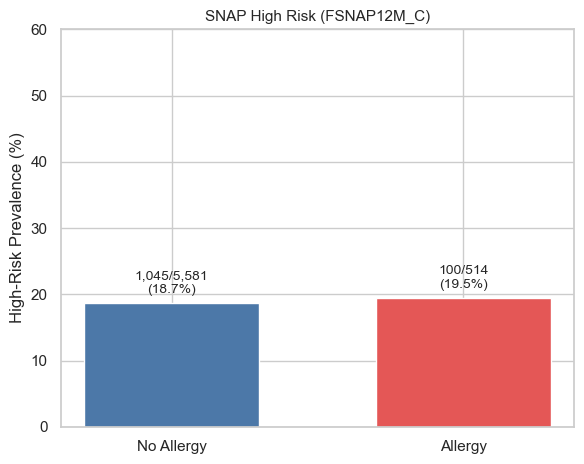

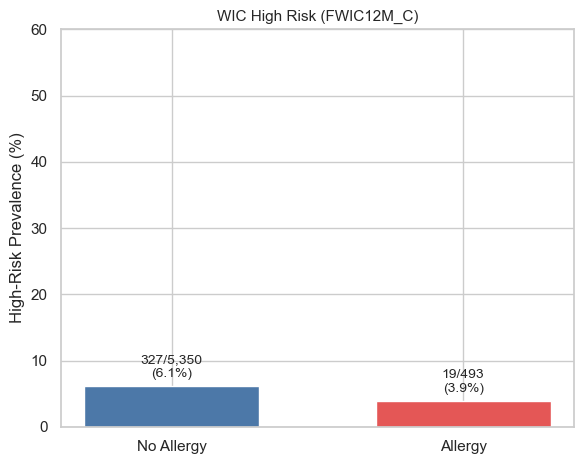

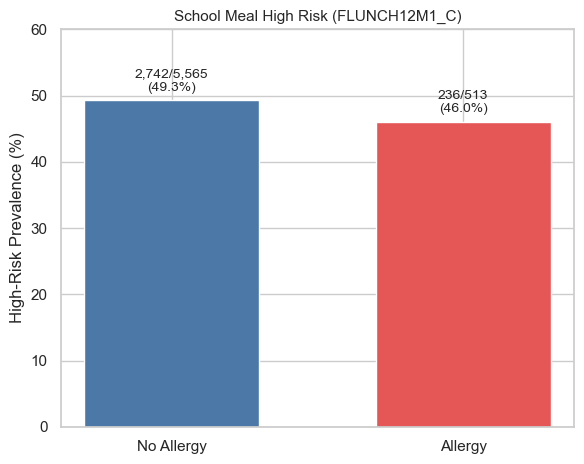

In [64]:
# -----------------------------------
# 1) Base data: age 5-17, keep both allergy groups
# -----------------------------------
df = children_with_age_range.copy()
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# -----------------------------------
# 2) Recode socioeconomic variables to binary risk
# -----------------------------------
def recode_notcov(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 1  # uninsured = high risk
    out[s == 2] = 0  # insured = low risk
    return out

def recode_cover(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 0
    out[s.isin([2, 4])] = 1
    return out

def recode_yesno_risk(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 1
    out[s == 2] = 0
    return out

df["notcov_risk"] = recode_notcov(df["NOTCOV_C"])
df["cover_risk"] = recode_cover(df["COVER_C"])
df["snap_risk"] = recode_yesno_risk(df["FSNAP12M_C"])
df["wic_risk"] = recode_yesno_risk(df["FWIC12M_C"])
df["meal_risk"] = recode_yesno_risk(df["FLUNCH12M1_C"])

# -----------------------------------
# 3) Plot each variable separately (1 row, 1 chart each)
# -----------------------------------
sns.set_theme(style="whitegrid")

plot_specs = [
    ("notcov_risk", "Insurance Status High Risk (NOTCOV_C)"),
    ("cover_risk", "Insurance Type High Risk (COVER_C)"),
    ("snap_risk", "SNAP High Risk (FSNAP12M_C)"),
    ("wic_risk", "WIC High Risk (FWIC12M_C)"),
    ("meal_risk", "School Meal High Risk (FLUNCH12M1_C)"),
]

for col, title in plot_specs:
    sub = df.dropna(subset=["food_allergy", col]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[col] = sub[col].astype(int)

    totals = sub.groupby("food_allergy")[col].size().reindex([0, 1], fill_value=0)
    high_counts = sub.groupby("food_allergy")[col].sum().reindex([0, 1], fill_value=0)
    pct = (high_counts / totals.replace(0, np.nan) * 100).fillna(0)

    plt.figure(figsize=(6, 4.8))
    bars = plt.bar(
        ["No Allergy", "Allergy"],
        [pct.loc[0], pct.loc[1]],
        color=["#4C78A8", "#E45756"],
        width=0.6
    )

    for i, grp in enumerate([0, 1]):
        cnt = int(high_counts.loc[grp])
        tot = int(totals.loc[grp])
        p = float(pct.loc[grp])
        plt.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 1.0,
            f"{cnt:,}/{tot:,}\n({p:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.title(title, fontsize=11)
    plt.ylabel("High-Risk Prevalence (%)")
    plt.ylim(0, 60)
    plt.tight_layout()
    plt.show()


Crosstab: Count


,education_group,No Allergy,Allergy
0,Low,1491,95
1,Medium,1422,140
2,High,2627,281


Crosstab: Row Percentage


,education_group,No Allergy (%),Allergy (%)
0,Low,94.01,5.99
1,Medium,91.04,8.96
2,High,90.34,9.66


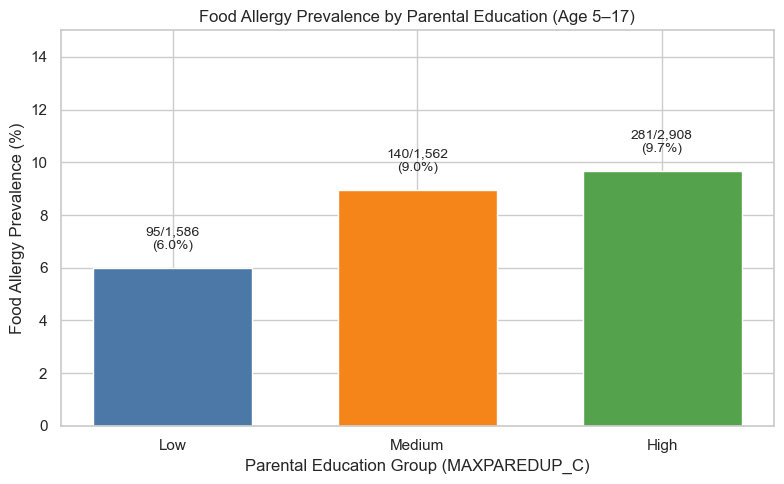

In [65]:
# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# (1) Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# (2) CURFOOD_C recode: 1->1, 2->0, else NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# (3) MAXPAREDUP_C recode to 3 education groups
maxedu = pd.to_numeric(df["MAXPAREDUP_C"], errors="coerce")

# Use np.select with pd.NA to avoid dtype conflict
conditions = [
    maxedu.between(0, 4),   # Low
    maxedu.between(5, 7),   # Medium
    maxedu.between(8, 10),  # High
]
choices = ["Low", "Medium", "High"]

df["education_group"] = pd.Series(
    np.select(conditions, choices, default=pd.NA),
    index=df.index,
    dtype="object"
)

# Remove missing values for analysis
analysis_df = df.dropna(subset=["education_group", "food_allergy"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["education_group"] = pd.Categorical(
    analysis_df["education_group"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

# -----------------------------------
# 2) Crosstab (count + row %)
# -----------------------------------
ct_count = pd.crosstab(analysis_df["education_group"], analysis_df["food_allergy"])
ct_count = ct_count.reindex(index=["Low", "Medium", "High"], columns=[0, 1], fill_value=0)
ct_count.columns = ["No Allergy", "Allergy"]

ct_pct = pd.crosstab(
    analysis_df["education_group"],
    analysis_df["food_allergy"],
    normalize="index"
) * 100
ct_pct = ct_pct.reindex(index=["Low", "Medium", "High"], columns=[0, 1], fill_value=0)
ct_pct.columns = ["No Allergy (%)", "Allergy (%)"]

ct_pct_show = ct_pct.rename_axis(None).reset_index(names="education_group")
ct_count_show = ct_count.rename_axis(None).reset_index(names="education_group")

print("Crosstab: Count")
display(ct_count_show)

print("Crosstab: Row Percentage")
display(ct_pct_show.round(2))

# -----------------------------------
# 3) Bar chart
# -----------------------------------
prev_pct = ct_pct["Allergy (%)"]
allergy_counts = ct_count["Allergy"]
group_totals = ct_count.sum(axis=1)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
bars = plt.bar(prev_pct.index, prev_pct.values, color=["#4C78A8", "#F58518", "#54A24B"], width=0.65)

for i, bar in enumerate(bars):
    grp = prev_pct.index[i]
    cnt = int(allergy_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = prev_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Food Allergy Prevalence by Parental Education (Age 5–17)")
plt.xlabel("Parental Education Group (MAXPAREDUP_C)")
plt.ylabel("Food Allergy Prevalence (%)")
plt.ylim(0, 15)
plt.tight_layout()
plt.show()


Crosstab (count):


food_insecure,High/Marginal,Low/Very Low
food_allergy,,
No Allergy,4922,682
Allergy,433,84


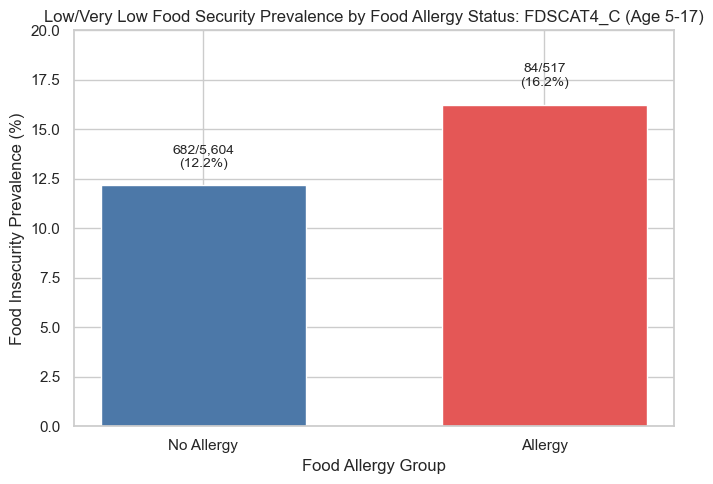

Chi-square test result
chi2 = 6.8211
p-value = 0.00900854
dof = 1


In [66]:
# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# (1) Age range: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# (2) CURFOOD_C: 1=Allergy, 2=No Allergy, others=NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# (3) FDSCAT4_C -> food_insecure
# 3,4 -> 1 (Low/Very Low), 1,2 -> 0 (High/Marginal), others(8,etc.) -> NaN
fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3, 4]), 1,
    np.where(fd.isin([1, 2]), 0, np.nan)
)

# Remove missing
analysis_df = df.dropna(subset=["food_allergy", "food_insecure"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["food_insecure"] = analysis_df["food_insecure"].astype(int)

# -----------------------------------
# 2) Crosstab + prevalence
# -----------------------------------
ct = pd.crosstab(analysis_df["food_allergy"], analysis_df["food_insecure"]).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0
)
# index: 0 No allergy, 1 Allergy
# col 1: Low/Very Low food security count

insecure_counts = ct[1]
totals = ct.sum(axis=1)
insecure_pct = (insecure_counts / totals * 100)

# Display crosstab
ct_show = ct.rename(index={0: "No Allergy", 1: "Allergy"},
                    columns={0: "High/Marginal", 1: "Low/Very Low"})
print("Crosstab (count):")
display(ct_show)

# -----------------------------------
# 3) Visualization
# -----------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

x_labels = ["No Allergy", "Allergy"]
y_vals = [insecure_pct.loc[0], insecure_pct.loc[1]]
bars = plt.bar(x_labels, y_vals, color=["#4C78A8", "#E45756"], width=0.6)

for i, grp in enumerate([0, 1]):
    cnt = int(insecure_counts.loc[grp])
    tot = int(totals.loc[grp])
    pct = float(insecure_pct.loc[grp])
    plt.text(
        bars[i].get_x() + bars[i].get_width() / 2,
        bars[i].get_height() + 0.8,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Low/Very Low Food Security Prevalence by Food Allergy Status: FDSCAT4_C (Age 5-17)")
plt.xlabel("Food Allergy Group")
plt.ylabel("Food Insecurity Prevalence (%)")
plt.ylim(0, 20)
plt.tight_layout()
plt.show()

# -----------------------------------
# 4) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct)

print("Chi-square test result")
print(f"chi2 = {chi2:.4f}")
print(f"p-value = {p_value:.6g}")
print(f"dof = {dof}")


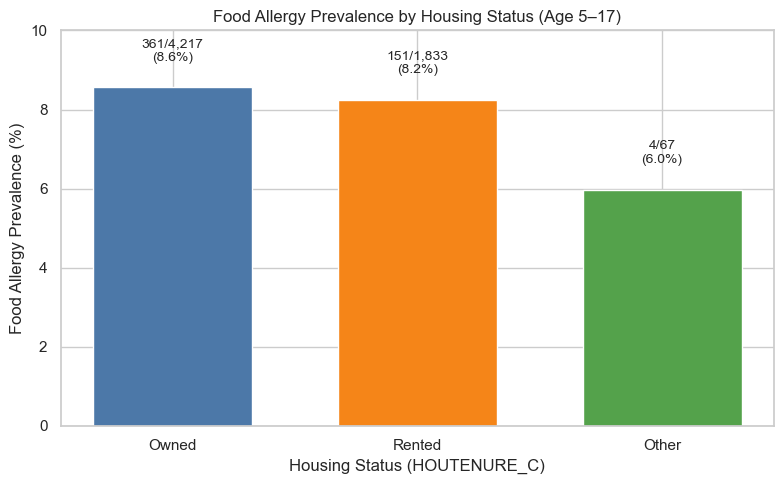

In [67]:
#| hide_input
# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# (1) Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# (2) CURFOOD_C recode: 1->1, 2->0, else NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# (3) HOUTENURE_C recode
house = pd.to_numeric(df["HOUTENURE_C"], errors="coerce")
housing_map = {1: "Owned", 2: "Rented", 3: "Other"}
df["housing_group"] = house.map(housing_map)  # 7,8,9 and others -> NaN

# Optional: exclude "Other" if desired
# df.loc[df["housing_group"] == "Other", "housing_group"] = np.nan

# Remove missing values
analysis_df = df.dropna(subset=["housing_group", "food_allergy"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["housing_group"] = pd.Categorical(
    analysis_df["housing_group"],
    categories=["Owned", "Rented", "Other"],
    ordered=True
)

# -----------------------------------
# 2) Crosstab (count + row %)
# -----------------------------------
ct_count = pd.crosstab(analysis_df["housing_group"], analysis_df["food_allergy"])
ct_count = ct_count.reindex(index=["Owned", "Rented", "Other"], columns=[0, 1], fill_value=0)
ct_count.columns = ["No Allergy", "Allergy"]

ct_pct = pd.crosstab(
    analysis_df["housing_group"],
    analysis_df["food_allergy"],
    normalize="index"
) * 100
ct_pct = ct_pct.reindex(index=["Owned", "Rented", "Other"], columns=[0, 1], fill_value=0)
ct_pct.columns = ["No Allergy (%)", "Allergy (%)"]

# Display tables with one-line header style
# print("Crosstab: Count")
# display(ct_count.rename_axis(None).reset_index(names="housing_group"))

# print("Crosstab: Row Percentage")
# display(ct_pct.round(2).rename_axis(None).reset_index(names="housing_group"))

# -----------------------------------
# 3) Bar chart
# -----------------------------------
prev_pct = ct_pct["Allergy (%)"]
allergy_counts = ct_count["Allergy"]
group_totals = ct_count.sum(axis=1)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
bars = plt.bar(
    prev_pct.index,
    prev_pct.values,
    color=["#4C78A8", "#F58518", "#54A24B"],
    width=0.65
)

for i, bar in enumerate(bars):
    grp = prev_pct.index[i]
    cnt = int(allergy_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = prev_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Food Allergy Prevalence by Housing Status (Age 5–17)")
plt.xlabel("Housing Status (HOUTENURE_C)")
plt.ylabel("Food Allergy Prevalence (%)")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


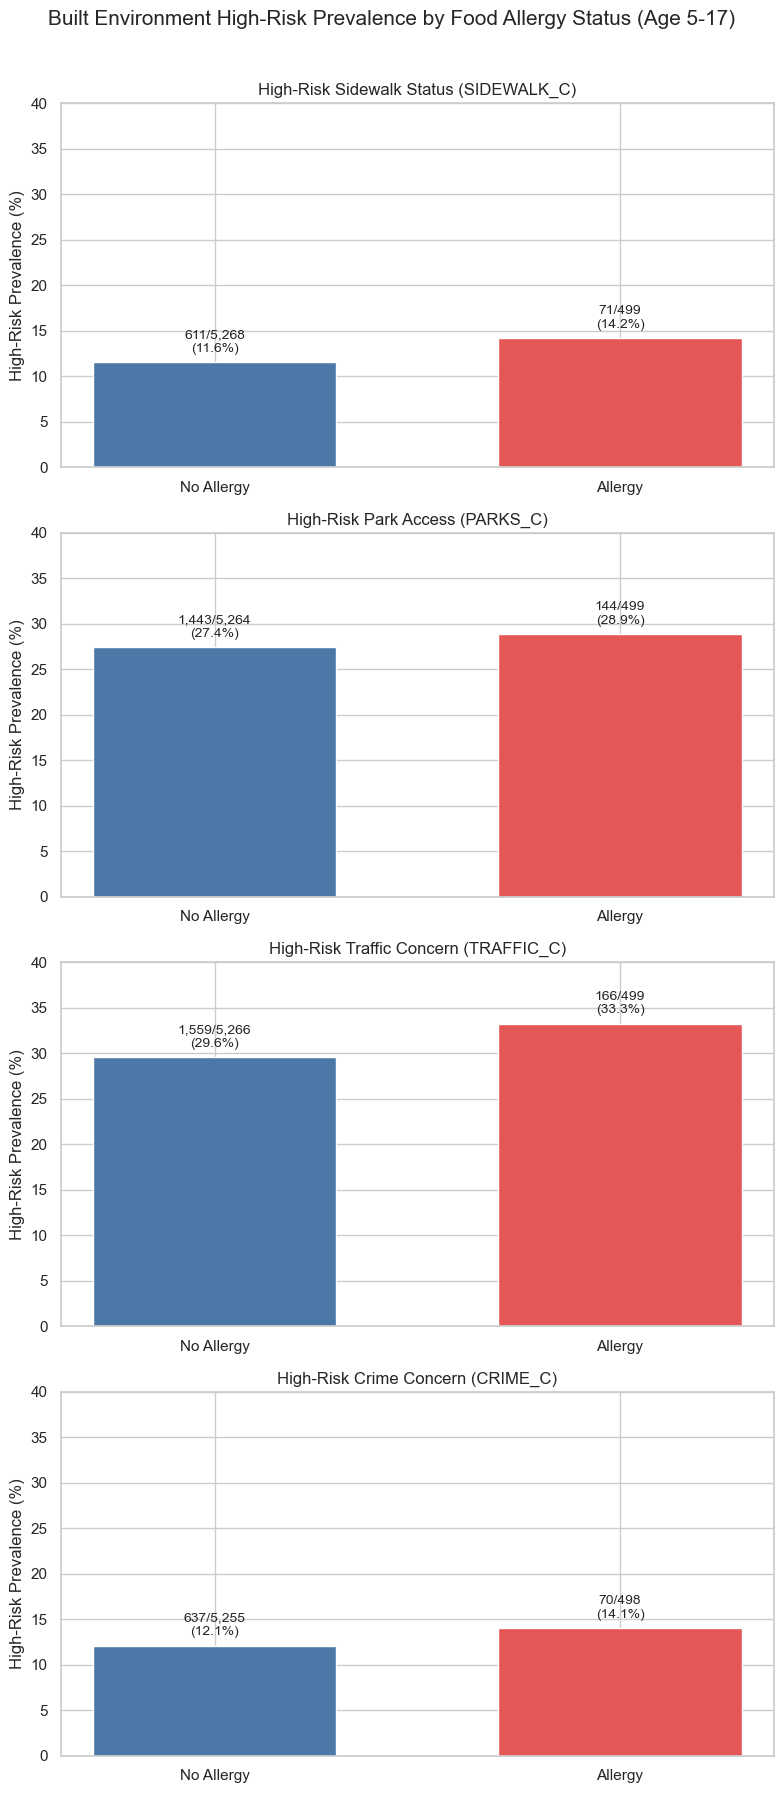

In [68]:
# -----------------------------
# 1) Filter: age 5-17 + keep both allergy groups
# -----------------------------
df = child_data.copy()

age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# -----------------------------
# 2) Recode built environment to high-risk indicators
# -----------------------------
def to_num(s):
    return pd.to_numeric(s, errors="coerce")

sidewalk = to_num(df["SIDEWALK_C"])
parks = to_num(df["PARKS_C"])
traffic = to_num(df["TRAFFIC_C"])
crime = to_num(df["CRIME_C"])

# High-risk:
# Sidewalk/Parks: No(2)=1 high-risk, Yes(1)=0
# Traffic/Crime: Yes(1)=1 high-risk, No(2)=0
df["sidewalk_high_risk"] = np.where(sidewalk == 2, 1, np.where(sidewalk == 1, 0, np.nan))
df["parks_high_risk"] = np.where(parks == 2, 1, np.where(parks == 1, 0, np.nan))
df["traffic_high_risk"] = np.where(traffic == 1, 1, np.where(traffic == 2, 0, np.nan))
df["crime_high_risk"] = np.where(crime == 1, 1, np.where(crime == 2, 0, np.nan))

# -----------------------------
# 3) 4x1 subplot (one plot per row)
# -----------------------------
sns.set_theme(style="whitegrid")

plot_specs = [
    ("sidewalk_high_risk", "High-Risk Sidewalk Status (SIDEWALK_C)"),
    ("parks_high_risk", "High-Risk Park Access (PARKS_C)"),
    ("traffic_high_risk", "High-Risk Traffic Concern (TRAFFIC_C)"),
    ("crime_high_risk", "High-Risk Crime Concern (CRIME_C)"),
]

fig, axes = plt.subplots(4, 1, figsize=(8, 18), sharey=True)

for ax, (col, title) in zip(axes, plot_specs):
    sub = df.dropna(subset=["food_allergy", col]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[col] = sub[col].astype(int)

    totals = sub.groupby("food_allergy")[col].size().reindex([0, 1], fill_value=0)
    high_counts = sub.groupby("food_allergy")[col].sum().reindex([0, 1], fill_value=0)
    pcts = (high_counts / totals.replace(0, np.nan) * 100).fillna(0)

    bars = ax.bar(
        [0, 1],
        [pcts.loc[0], pcts.loc[1]],
        color=["#4C78A8", "#E45756"],
        width=0.6
    )

    for i, grp in enumerate([0, 1]):
        cnt = int(high_counts.loc[grp])
        tot = int(totals.loc[grp])
        pct = float(pcts.loc[grp])
        ax.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 0.8,
            f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    ax.set_title(title)
    ax.set_xticks([0, 1], ["No Allergy", "Allergy"])
    ax.set_ylim(0, 40)
    ax.set_ylabel("High-Risk Prevalence (%)")

fig.suptitle("Built Environment High-Risk Prevalence by Food Allergy Status (Age 5-17)", fontsize=15, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

Poor health among children with food allergy only:
36/522 (6.90%)


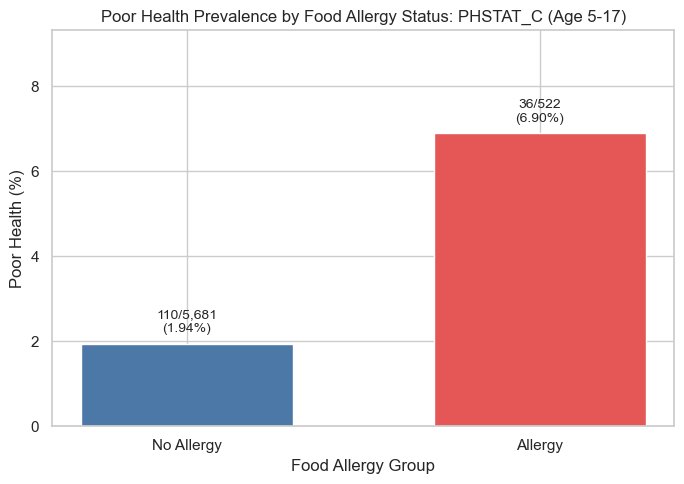


Crosstab (count):


poor_health,Not Poor,Poor
food_allergy,,
No Allergy,5571,110
Allergy,486,36


chi2 = 49.0442
p-value = 2.50256e-12
dof = 1


In [70]:
# CURFOOD_C vs. PHSTAT_C

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# CURFOOD_C recode: 1=Allergy, 2=No allergy, others=NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# PHSTAT_C recode: 4=Poor health(1), 1/2/3=Not poor(0), 7/8/9=NaN
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph == 4, 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# Remove missing
analysis_df = df.dropna(subset=["food_allergy", "poor_health"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["poor_health"] = analysis_df["poor_health"].astype(int)

# -----------------------------------
# 2) Analysis
# -----------------------------------
# (1) Poor health prevalence among allergy group only
allergy_only = analysis_df[analysis_df["food_allergy"] == 1]
allergy_poor_rate = allergy_only["poor_health"].mean() * 100
allergy_poor_count = int(allergy_only["poor_health"].sum())
allergy_total = len(allergy_only)

print("Poor health among children with food allergy only:")
print(f"{allergy_poor_count:,}/{allergy_total:,} ({allergy_poor_rate:.2f}%)")

# (2) Compare prevalence by allergy status
ct_count = pd.crosstab(analysis_df["food_allergy"], analysis_df["poor_health"]).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0
)
# index: 0 No allergy, 1 Allergy; column 1 = poor health count
poor_pct = (ct_count[1] / ct_count.sum(axis=1) * 100)
poor_pct.index = ["No Allergy", "Allergy"]

poor_counts = ct_count[1].copy()
poor_counts.index = ["No Allergy", "Allergy"]
group_totals = ct_count.sum(axis=1).copy()
group_totals.index = ["No Allergy", "Allergy"]

# -----------------------------------
# 3) Visualization
# -----------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
bars = plt.bar(poor_pct.index, poor_pct.values, color=["#4C78A8", "#E45756"], width=0.6)

for i, bar in enumerate(bars):
    grp = poor_pct.index[i]
    cnt = int(poor_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = poor_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{cnt:,}/{tot:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Poor Health Prevalence by Food Allergy Status: PHSTAT_C (Age 5-17)")
plt.xlabel("Food Allergy Group")
plt.ylabel("Poor Health (%)")
plt.ylim(0, max(5, poor_pct.max() * 1.35))
plt.tight_layout()
plt.show()

# -----------------------------------
# 4) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct_count)

print("\nCrosstab (count):")
display(ct_count.rename(index={0: "No Allergy", 1: "Allergy"},
                        columns={0: "Not Poor", 1: "Poor"}))

print(f"chi2 = {chi2:.4f}")
print(f"p-value = {p_value:.6g}")
print(f"dof = {dof}")
